In [123]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install wordcloud
from wordcloud import WordCloud

In [94]:
df = pd.read_csv("/content/Diagnóstico de Agentes de IA y Automatización(Sheet1) (1).csv", encoding='latin1')
df

,Id,Hora de inicio,Hora de finalización,Correo electrónico,Nombre,Nombre del Agente,Área responsable,Responsable (Nombre y Posición),Tipo de agente,¿Qué capacidades aumenta?,...,Reduce esfuerzo humano\n,Reduce costo operativo\n,Escala mejor que el proceso anterior\n,Reduce tiempos de respuesta\n,"¿Lo hace mejor, más rápido o más barato?\n",Si el agente desaparece mañana\n¿Qué perderíamos?,¿Dónde sigue siendo indispensable un humano?,¿Cuál fue la ultima vez que has usado tu agente y para que proyecto?,¿En qué tareas y/o actividades se ha probado el agente?,¿Qué le falta al agente?
0,1,6/8/2026 16:43,6/8/2026 16:53,1167486@onuriscp.com,Fernando Dorantes Nieto,NerdAfore,Portafolio,"Fernando Dorantes Nieto, Data Scientist",Knowledge Agent  Busca y recupera información...,Velocidad;Productividad;Escalabilidad;Consiste...,...,4,4,5,4,Mejor,Velocidad;Productividad;Conocimiento;,Decisión final;Gestión de conflictos;Creatividad;,NaN,En el proyecto de AFORE,Más casos de uso;Más datos;
1,2,6/8/2026 16:58,6/8/2026 17:00,1167486@onuriscp.com,Fernando Dorantes Nieto,ChismesitoGPT,Portafolio,"Fernando Dorantes Nieto, Data Scientist",Analyst Agent  Analiza datos e identifica pat...,Velocidad;Productividad;Calidad;Consistencia;T...,...,3,3,4,2,Más rápido,Productividad; Velocidad;,Validación;Decisión final;Creatividad;,NaN,En diversas tareas de web scraping,Mejor UX;Mejor integración;Más datos;Mayor aut...
2,3,6/8/2026 17:01,6/8/2026 17:03,1167486@onuriscp.com,Fernando Dorantes Nieto,Agente Integrador Servisirius a Vibe Coding,Portafolio,"Fernando Dorantes Nieto, Data Scientist",Knowledge Agent  Busca y recupera información...,Productividad;Velocidad;Escalabilidad;Precisió...,...,3,2,3,3,Mejor,Productividad; Velocidad;,Validación;Empatía;Relación con cliente;,NaN,"Aún no se ha probado, pero es totalmente prome...",Más datos;Mejor contexto;Mejor integración;Mej...
3,4,6/9/2026 11:16,6/9/2026 11:22,1081043@onuriscp.com,Alejandro Javier Franco,Nerdadore,Modelos de Negocio,Alejandro Javier - Investigación,Knowledge Agent  Busca y recupera información...,Productividad;Aprendizaje organizacional;Escal...,...,4,4,4,4,Más rápido,Velocidad,Validación;Negociación;Relación con cliente,La procuro usar dos veces a la semana para con...,"EN EL ENTENDIMIENTO DE LA NORMATIVIDAD,",Mejor contexto;Mejor adopción
4,5,6/9/2026 11:10,6/9/2026 11:24,1158181@onuriscp.com,Andrea Cecilia Sanchez Nanez,Chris Detective,Investigación,"era de chris, no he reasignado quien se queda ...",Analyst Agent  Analiza datos e identifica pat...,Velocidad;Calidad,...,4,4,3,4,Más rápido,Velocidad;Conocimiento;Nada importante,Validación;Decisión final,para tendencias del segmento de banca empresar...,se probó con tendencias que habíamos investiga...,Mejor contexto;Mejor precisión;Mejor UX
5,6,6/9/2026 11:33,6/9/2026 11:47,1213953@onuriscp.com,Eduardo Lopez Santana,Search bot Max 2.0,Modelos de negocio,Eduardo Lopez Santana - Consultor de investiga...,Synthesis Agent  Resume y sintetiza informaci...,Velocidad;Productividad;Calidad;Precisión,...,5,2,4,5,Más rápido,Velocidad;Productividad;Atención personalizada,Validación;Creatividad;Relación con cliente,La última vez que use el agente fue para busca...,"Para buscar y encontrar más rápido estudios, i...",Mejor integración;Mejor UX;Mejor precisión
6,7,6/9/2026 11:22,6/9/2026 11:52,112637@onuriscp.com,Erik Javier Gonzalez Lopez,Perplexity,Modelos de Negocio,"Erik Gonzalez, Trainee",Knowledge Agent  Busca y recupera información...,Velocidad;Precisión;Consistencia,...,5,5,5,5,Mejor,Velocidad;Productividad,Validación;Decisión final;Creatividad,Dimensionamientos,Investigación,Mejor UX;Más casos de uso


In [95]:
df['Nombre del Agente'] = df['Nombre del Agente'].str.replace('Nerdadore', 'NerdAfore')
display(df.head())

,Id,Hora de inicio,Hora de finalización,Correo electrónico,Nombre,Nombre del Agente,Área responsable,Responsable (Nombre y Posición),Tipo de agente,¿Qué capacidades aumenta?,...,Reduce esfuerzo humano\n,Reduce costo operativo\n,Escala mejor que el proceso anterior\n,Reduce tiempos de respuesta\n,"¿Lo hace mejor, más rápido o más barato?\n",Si el agente desaparece mañana\n¿Qué perderíamos?,¿Dónde sigue siendo indispensable un humano?,¿Cuál fue la ultima vez que has usado tu agente y para que proyecto?,¿En qué tareas y/o actividades se ha probado el agente?,¿Qué le falta al agente?
0,1,6/8/2026 16:43,6/8/2026 16:53,1167486@onuriscp.com,Fernando Dorantes Nieto,NerdAfore,Portafolio,"Fernando Dorantes Nieto, Data Scientist",Knowledge Agent  Busca y recupera información...,Velocidad;Productividad;Escalabilidad;Consiste...,...,4,4,5,4,Mejor,Velocidad;Productividad;Conocimiento;,Decisión final;Gestión de conflictos;Creatividad;,NaN,En el proyecto de AFORE,Más casos de uso;Más datos;
1,2,6/8/2026 16:58,6/8/2026 17:00,1167486@onuriscp.com,Fernando Dorantes Nieto,ChismesitoGPT,Portafolio,"Fernando Dorantes Nieto, Data Scientist",Analyst Agent  Analiza datos e identifica pat...,Velocidad;Productividad;Calidad;Consistencia;T...,...,3,3,4,2,Más rápido,Productividad; Velocidad;,Validación;Decisión final;Creatividad;,NaN,En diversas tareas de web scraping,Mejor UX;Mejor integración;Más datos;Mayor aut...
2,3,6/8/2026 17:01,6/8/2026 17:03,1167486@onuriscp.com,Fernando Dorantes Nieto,Agente Integrador Servisirius a Vibe Coding,Portafolio,"Fernando Dorantes Nieto, Data Scientist",Knowledge Agent  Busca y recupera información...,Productividad;Velocidad;Escalabilidad;Precisió...,...,3,2,3,3,Mejor,Productividad; Velocidad;,Validación;Empatía;Relación con cliente;,NaN,"Aún no se ha probado, pero es totalmente prome...",Más datos;Mejor contexto;Mejor integración;Mej...
3,4,6/9/2026 11:16,6/9/2026 11:22,1081043@onuriscp.com,Alejandro Javier Franco,NerdAfore,Modelos de Negocio,Alejandro Javier - Investigación,Knowledge Agent  Busca y recupera información...,Productividad;Aprendizaje organizacional;Escal...,...,4,4,4,4,Más rápido,Velocidad,Validación;Negociación;Relación con cliente,La procuro usar dos veces a la semana para con...,"EN EL ENTENDIMIENTO DE LA NORMATIVIDAD,",Mejor contexto;Mejor adopción
4,5,6/9/2026 11:10,6/9/2026 11:24,1158181@onuriscp.com,Andrea Cecilia Sanchez Nanez,Chris Detective,Investigación,"era de chris, no he reasignado quien se queda ...",Analyst Agent  Analiza datos e identifica pat...,Velocidad;Calidad,...,4,4,3,4,Más rápido,Velocidad;Conocimiento;Nada importante,Validación;Decisión final,para tendencias del segmento de banca empresar...,se probó con tendencias que habíamos investiga...,Mejor contexto;Mejor precisión;Mejor UX


In [96]:
df.columns

Index(['Id', 'Hora de inicio', 'Hora de finalización', 'Correo electrónico',
       'Nombre', 'Nombre del Agente', 'Área responsable',
       'Responsable (Nombre y Posición)', 'Tipo de agente',
       '¿Qué capacidades aumenta?', 'Nivel de autonomía',
       '¿Cuál es el baseline del agente?(Cuántas horas demoraría la misma tarea en hacerse si no contáramos con el agente)',
       '¿Cuál es su objetivo principal?',
       '¿Cuál era el problema antes del agente?',
       '¿Cómo resolverían este problema antes de tener el agente?',
       'Resuelve el problema para el que fue creado\n',
       'Entrega resultados útiles\n', 'Reduce retrabajo\n',
       'La calidad es adecuada\n', 'Los usuarios volverían a usarlo\n',
       '¿Cumple su objetivo?\n', 'Ahorra tiempo\n', 'Reduce esfuerzo humano\n',
       'Reduce costo operativo\n', 'Escala mejor que el proceso anterior\n',
       'Reduce tiempos de respuesta\n',
       '¿Lo hace mejor, más rápido o más barato?\n',
       'Si el agente des

# Tipo de agente

In [97]:
tipo_agente_counts = df['Tipo de agente'].str.split(';', expand=True).stack().str.strip().value_counts()
display(tipo_agente_counts)

,count
"Knowledge Agent  Busca y recupera información (políticas, contratos, procedimientos)",5
"Synthesis Agent  Resume y sintetiza información (minutas, reportes, documentos largos)",5
"Analyst Agent  Analiza datos e identifica patrones (KPIs, anomalías, tendencias)",5
"Recommendation Agent  Sugiere acciones (priorización, siguiente mejor acción)",4
Orchestrator Agent  Coordina personas o sistemas (workflow completo),3
,3
"Content Agent  Genera contenido (correos, propuestas, presentaciones)",2
"Innovation Agent  Genera hipótesis, oportunidades o insights",2


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


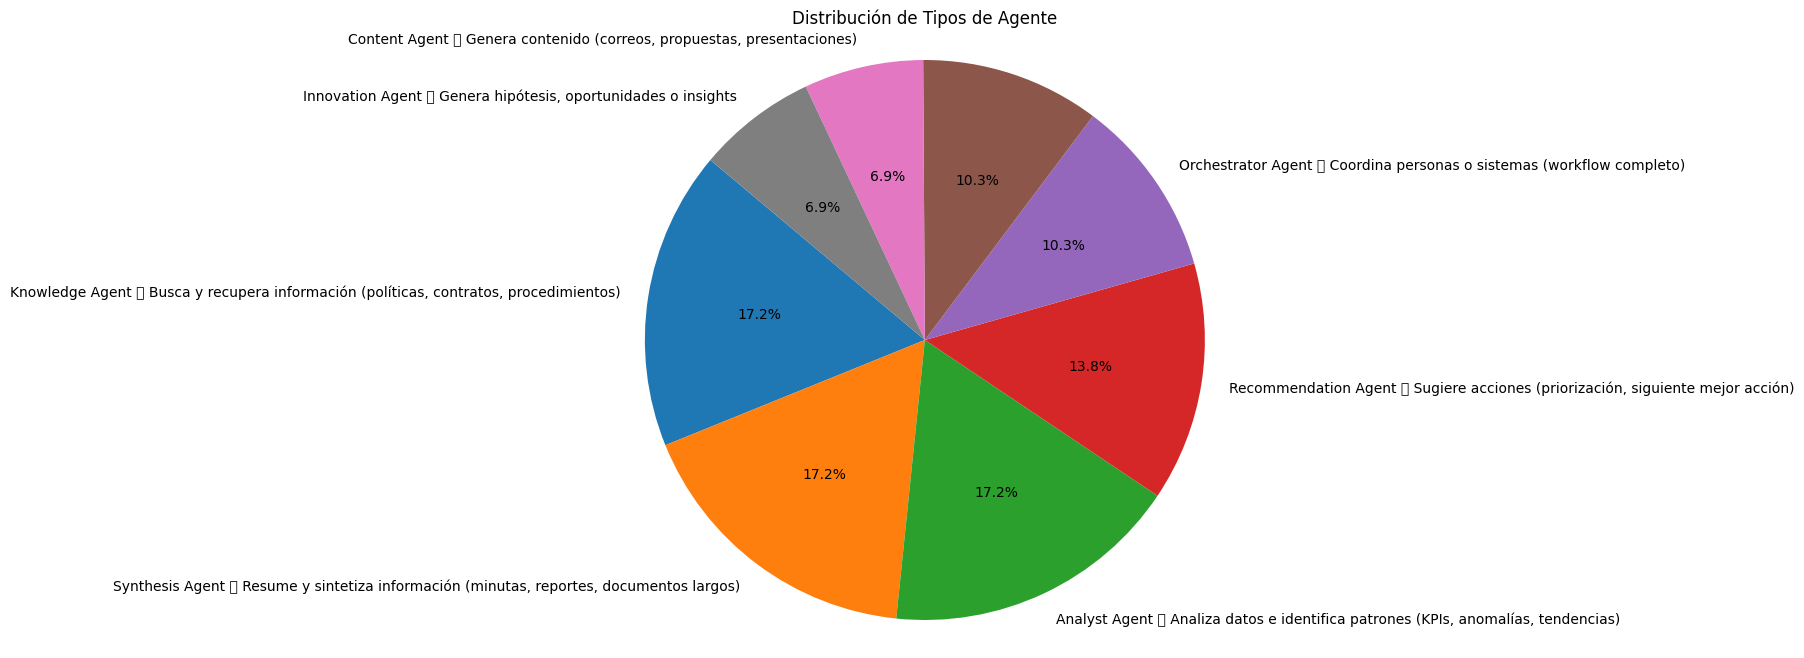

In [98]:
plt.figure(figsize=(10, 8))
plt.pie(tipo_agente_counts, labels=tipo_agente_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribución de Tipos de Agente')
plt.axis('equal')
plt.show()

In [99]:
capacidades_aumenta_counts = df['¿Qué capacidades aumenta?'].str.split(';', expand=True).stack().str.strip().value_counts()
display(capacidades_aumenta_counts)

,count
Velocidad,6
Productividad,5
Calidad,4
Consistencia,3
Escalabilidad,3
Precisión,3
,3
Toma de decisiones,2
Aprendizaje organizacional,2


### Relación entre Nombre del Agente y Tipo de Agente

In [100]:
agent_types_shortened_series = (
    tipo_agente_counts.index.to_series()
    .str.extract(r'(.*?Agent)', expand=False)
)

agent_types_shortened_series

,0
"Knowledge Agent  Busca y recupera información (políticas, contratos, procedimientos)",Knowledge Agent
"Synthesis Agent  Resume y sintetiza información (minutas, reportes, documentos largos)",Synthesis Agent
"Analyst Agent  Analiza datos e identifica patrones (KPIs, anomalías, tendencias)",Analyst Agent
"Recommendation Agent  Sugiere acciones (priorización, siguiente mejor acción)",Recommendation Agent
Orchestrator Agent  Coordina personas o sistemas (workflow completo),Orchestrator Agent
,NaN
"Content Agent  Genera contenido (correos, propuestas, presentaciones)",Content Agent
"Innovation Agent  Genera hipótesis, oportunidades o insights",Innovation Agent


In [101]:
df_counts = tipo_agente_counts.reset_index()
df_counts.columns = ['full_agent_type_description', 'count']

df_shortened = agent_types_shortened_series.reset_index()
df_shortened.columns = ['full_agent_type_description', 'agent_key']

df_merged = pd.merge(df_counts, df_shortened, on='full_agent_type_description', how='left')

display(df_merged)

,full_agent_type_description,count,agent_key
0,Knowledge Agent  Busca y recupera información...,5,Knowledge Agent
1,Synthesis Agent  Resume y sintetiza informaci...,5,Synthesis Agent
2,Analyst Agent  Analiza datos e identifica pat...,5,Analyst Agent
3,Recommendation Agent  Sugiere acciones (prior...,4,Recommendation Agent
4,Orchestrator Agent  Coordina personas o siste...,3,Orchestrator Agent
5,,3,NaN
6,"Content Agent  Genera contenido (correos, pro...",2,Content Agent
7,"Innovation Agent  Genera hipótesis, oportunid...",2,Innovation Agent


In [102]:
# Separar capacidades en filas
df_capacidades = df.copy()

df_capacidades['¿Qué capacidades aumenta?'] = (
    df_capacidades['¿Qué capacidades aumenta?']
    .str.split(';')
)

df_capacidades = df_capacidades.explode('¿Qué capacidades aumenta?')

# Limpiar espacios
df_capacidades['¿Qué capacidades aumenta?'] = (
    df_capacidades['¿Qué capacidades aumenta?']
    .str.strip()
)

# Eliminar vacíos
df_capacidades = df_capacidades[
    df_capacidades['¿Qué capacidades aumenta?'].notna()
]

df_capacidades = df_capacidades[
    df_capacidades['¿Qué capacidades aumenta?'] != ''
]

display(
    df_capacidades[
        ['Nombre del Agente', '¿Qué capacidades aumenta?']
    ].head(20)
)

,Nombre del Agente,¿Qué capacidades aumenta?
0,NerdAfore,Velocidad
0,NerdAfore,Productividad
0,NerdAfore,Escalabilidad
0,NerdAfore,Consistencia
0,NerdAfore,Toma de decisiones
0,NerdAfore,Aprendizaje organizacional
1,ChismesitoGPT,Velocidad
1,ChismesitoGPT,Productividad
1,ChismesitoGPT,Calidad
1,ChismesitoGPT,Consistencia


In [103]:
df_agents = df.copy()

df_agents['Tipo de agente'] = (
    df_agents['Tipo de agente']
    .str.split(';')
)

df_agents = df_agents.explode('Tipo de agente')

df_agents['Tipo de agente (Shortened)'] = (
    df_agents['Tipo de agente']
    .str.extract(
        r'(Knowledge Agent|Analyst Agent|Synthesis Agent|Recommendation Agent|Content Agent|Orchestrator Agent|Innovation Agent)',
        expand=False
    )
)

display(df_agents[['Nombre del Agente', 'Tipo de agente (Shortened)']].head())



,Nombre del Agente,Tipo de agente (Shortened)
0,NerdAfore,Knowledge Agent
0,NerdAfore,Synthesis Agent
0,NerdAfore,Recommendation Agent
0,NerdAfore,Content Agent
0,NerdAfore,NaN


Tipo de agente (Shortened),Analyst Agent,Content Agent,Innovation Agent,Knowledge Agent,Orchestrator Agent,Recommendation Agent,Synthesis Agent
Nombre del Agente,,,,,,,
Agente Integrador Servisirius a Vibe Coding,1,1,1,1,1,1,1
ChismesitoGPT,1,0,1,1,1,1,1
Chris Detective,1,0,0,0,0,0,0
NerdAfore,1,1,0,2,0,1,2
Perplexity,0,0,0,1,0,0,0
Search bot Max 2.0,1,0,0,0,1,1,1


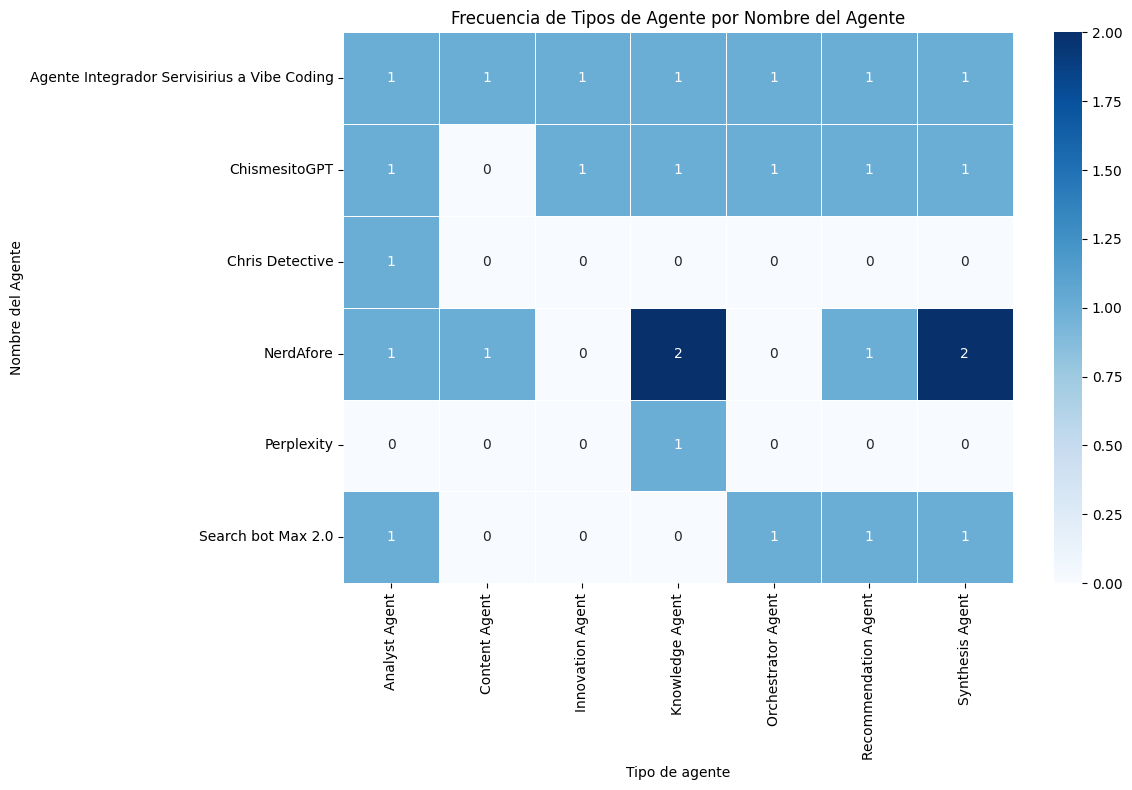

In [104]:
heatmap_data = pd.crosstab(
    df_agents['Nombre del Agente'],
    df_agents['Tipo de agente (Shortened)']
)

display(heatmap_data)

plt.figure(figsize=(12, 8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='g',
    cmap='Blues',
    linewidths=0.5
)

plt.title('Frecuencia de Tipos de Agente por Nombre del Agente')
plt.xlabel('Tipo de agente')
plt.ylabel('Nombre del Agente')

plt.tight_layout()
plt.show()


In [105]:
import pandas as pd

# Separar capacidades en filas
df_capacidades = df.copy()

df_capacidades['¿Qué capacidades aumenta?'] = (
    df_capacidades['¿Qué capacidades aumenta?']
    .str.split(';')
)

df_capacidades = df_capacidades.explode('¿Qué capacidades aumenta?')

# Limpiar espacios
df_capacidades['¿Qué capacidades aumenta?'] = (
    df_capacidades['¿Qué capacidades aumenta?']
    .str.strip()
)

# Eliminar vacíos
df_capacidades = df_capacidades[
    df_capacidades['¿Qué capacidades aumenta?'].notna()
]

df_capacidades = df_capacidades[
    df_capacidades['¿Qué capacidades aumenta?'] != ''
]

display(
    df_capacidades[
        ['Nombre del Agente', '¿Qué capacidades aumenta?']
    ].head(20)
)

,Nombre del Agente,¿Qué capacidades aumenta?
0,NerdAfore,Velocidad
0,NerdAfore,Productividad
0,NerdAfore,Escalabilidad
0,NerdAfore,Consistencia
0,NerdAfore,Toma de decisiones
0,NerdAfore,Aprendizaje organizacional
1,ChismesitoGPT,Velocidad
1,ChismesitoGPT,Productividad
1,ChismesitoGPT,Calidad
1,ChismesitoGPT,Consistencia


¿Qué capacidades aumenta?,Aprendizaje organizacional,Calidad,Consistencia,Escalabilidad,Precisión,Productividad,Toma de decisiones,Velocidad
Nombre del Agente,,,,,,,,
Agente Integrador Servisirius a Vibe Coding,0,1,0,1,1,1,0,1
ChismesitoGPT,0,1,1,0,0,1,1,1
Chris Detective,0,1,0,0,0,0,0,1
NerdAfore,2,0,1,2,0,2,1,1
Perplexity,0,0,1,0,1,0,0,1
Search bot Max 2.0,0,1,0,0,1,1,0,1


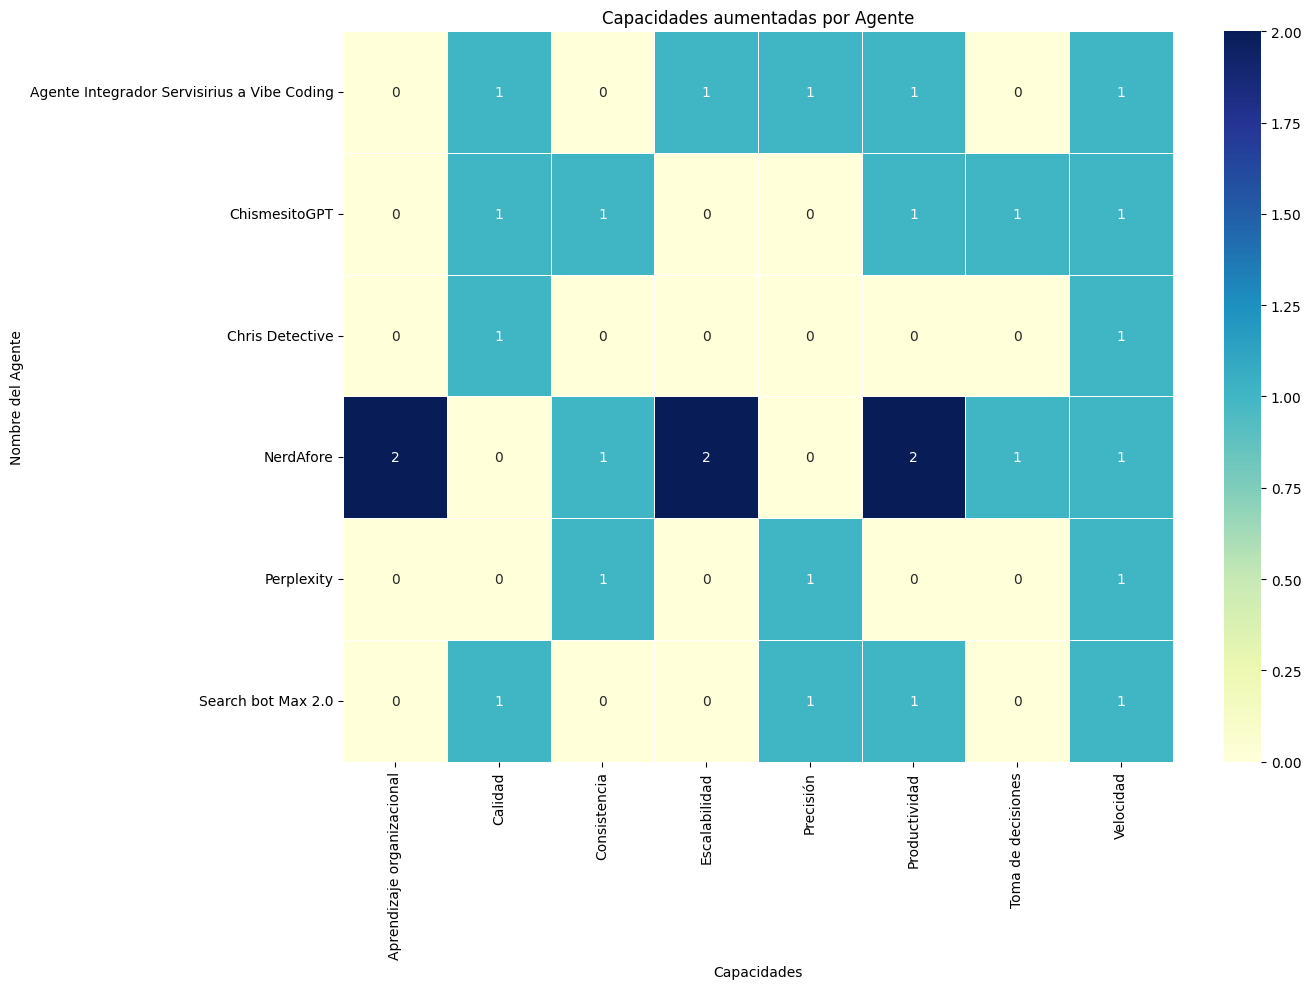

In [106]:
heatmap_capacidades = pd.crosstab(
    df_capacidades['Nombre del Agente'],
    df_capacidades['¿Qué capacidades aumenta?']
)

display(heatmap_capacidades)

plt.figure(figsize=(14,10))

sns.heatmap(
    heatmap_capacidades,
    annot=True,
    fmt='g',
    cmap='YlGnBu',
    linewidths=0.5
)

plt.title('Capacidades aumentadas por Agente')
plt.xlabel('Capacidades')
plt.ylabel('Nombre del Agente')

plt.tight_layout()
plt.show()

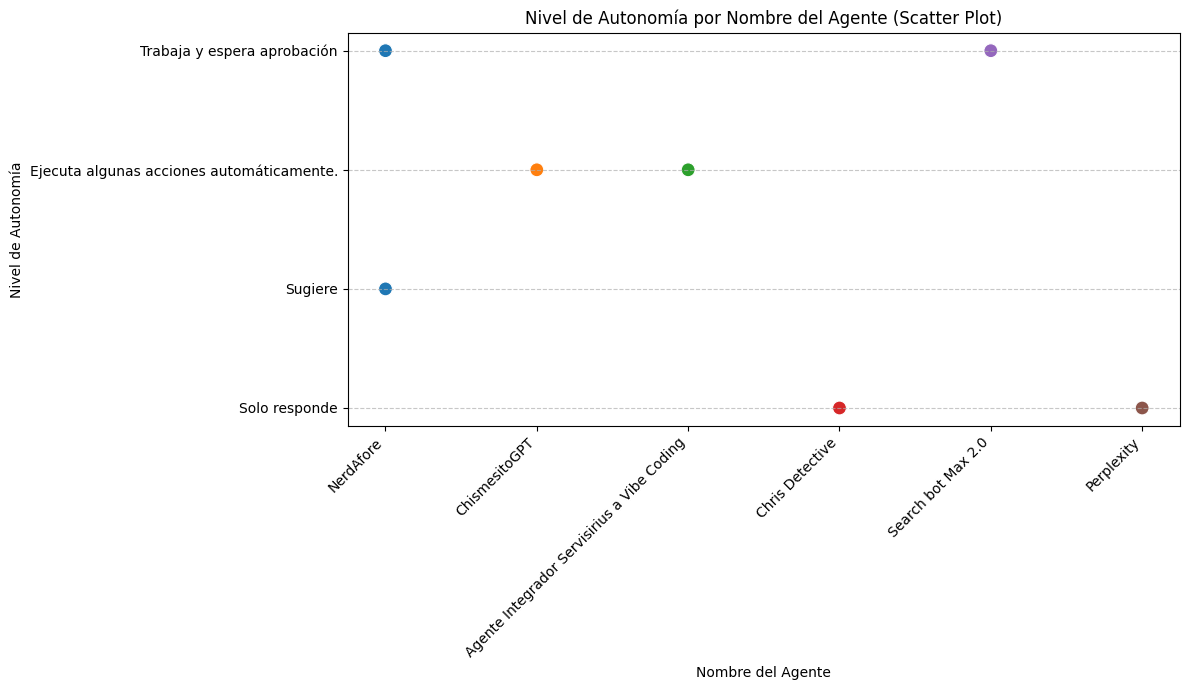

In [107]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='Nombre del Agente', y='Nivel de autonomía', data=df, s=100, hue='Nombre del Agente', legend=False)
plt.title('Nivel de Autonomía por Nombre del Agente (Scatter Plot)')
plt.xlabel('Nombre del Agente')
plt.ylabel('Nivel de Autonomía')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [108]:
# Separar objetivos en filas
df_objetivos = df.copy()

df_objetivos['¿Cuál es su objetivo principal?'] = (
    df_objetivos['¿Cuál es su objetivo principal?']
    .str.split(';')
)

df_objetivos = df_objetivos.explode('¿Cuál es su objetivo principal?')

# Limpiar espacios
df_objetivos['¿Cuál es su objetivo principal?'] = (
    df_objetivos['¿Cuál es su objetivo principal?']
    .str.strip()
)

# Eliminar vacíos (por el ; final)
df_objetivos = df_objetivos[
    df_objetivos['¿Cuál es su objetivo principal?'].notna()
]

df_objetivos = df_objetivos[
    df_objetivos['¿Cuál es su objetivo principal?'] != ''
]

# Ver resultado
display(
    df_objetivos[
        ['Nombre del Agente', '¿Cuál es su objetivo principal?']
    ].head(20)
)

,Nombre del Agente,¿Cuál es su objetivo principal?
0,NerdAfore,Analizar información
0,NerdAfore,Tomar decisiones
1,ChismesitoGPT,Buscar información
1,ChismesitoGPT,Analizar información
2,Agente Integrador Servisirius a Vibe Coding,Ahorrar tiempo
2,Agente Integrador Servisirius a Vibe Coding,Sintetizar información
3,NerdAfore,Ahorrar tiempo
3,NerdAfore,Otro
4,Chris Detective,Buscar información
4,Chris Detective,Sintetizar información


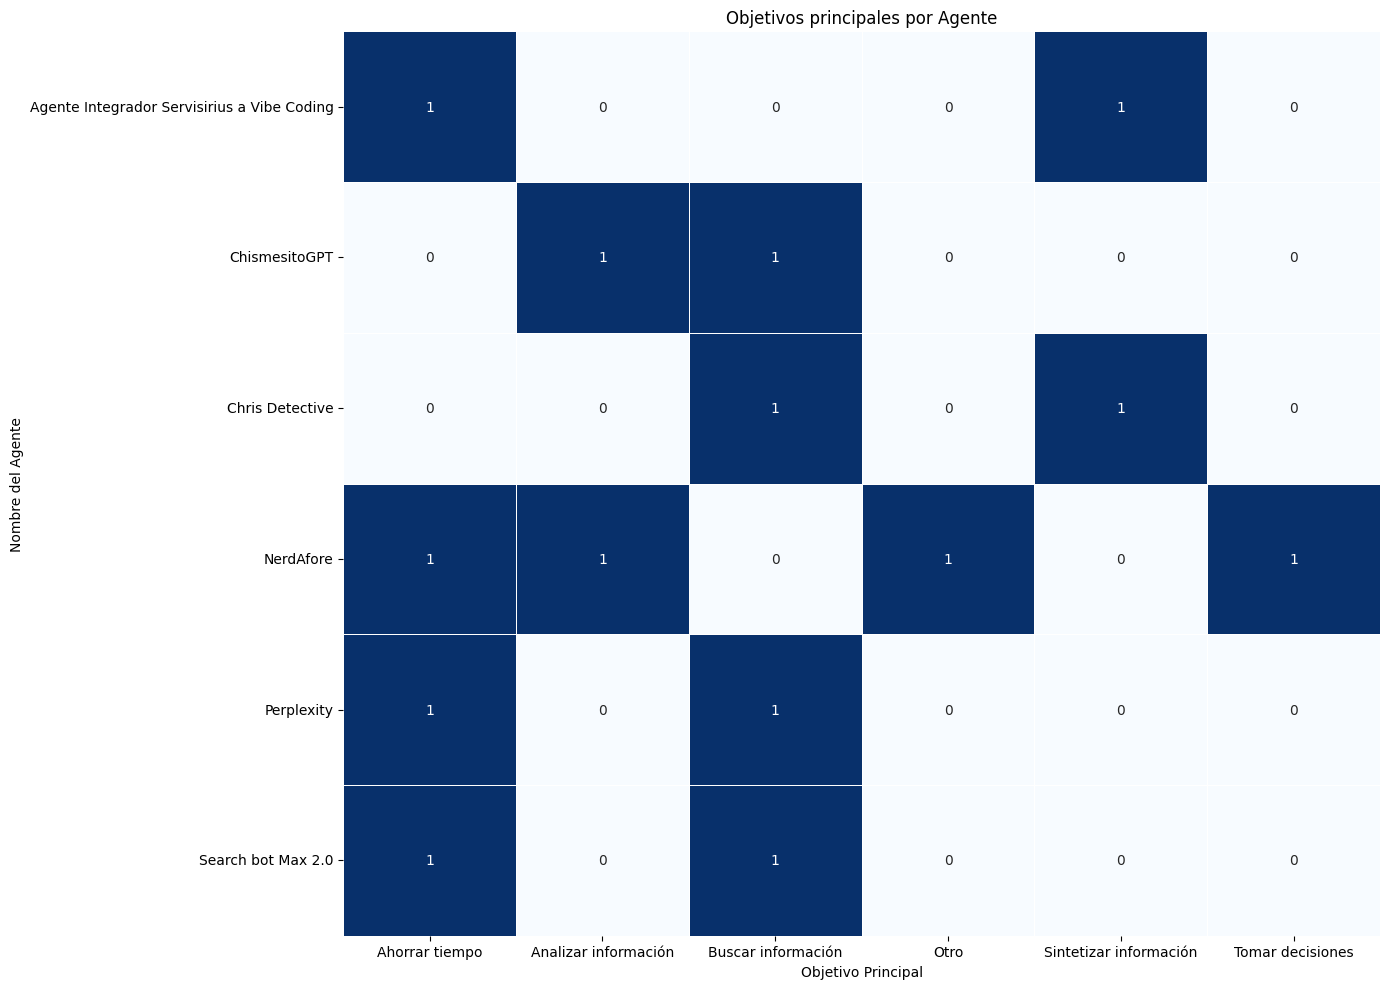

In [109]:
heatmap_objetivos = pd.crosstab(
    df_objetivos['Nombre del Agente'],
    df_objetivos['¿Cuál es su objetivo principal?']
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))

sns.heatmap(
    heatmap_objetivos,
    annot=True,
    cmap='Blues',
    cbar=False,
    linewidths=0.5
)

plt.title('Objetivos principales por Agente')
plt.xlabel('Objetivo Principal')
plt.ylabel('Nombre del Agente')

plt.tight_layout()
plt.show()

"¿Lo hace mejor, más rápido o más barato?",Mejor,Más rápido
Nombre del Agente,,
Agente Integrador Servisirius a Vibe Coding,1,0
ChismesitoGPT,0,1
Chris Detective,0,1
NerdAfore,1,1
Perplexity,1,0
Search bot Max 2.0,0,1


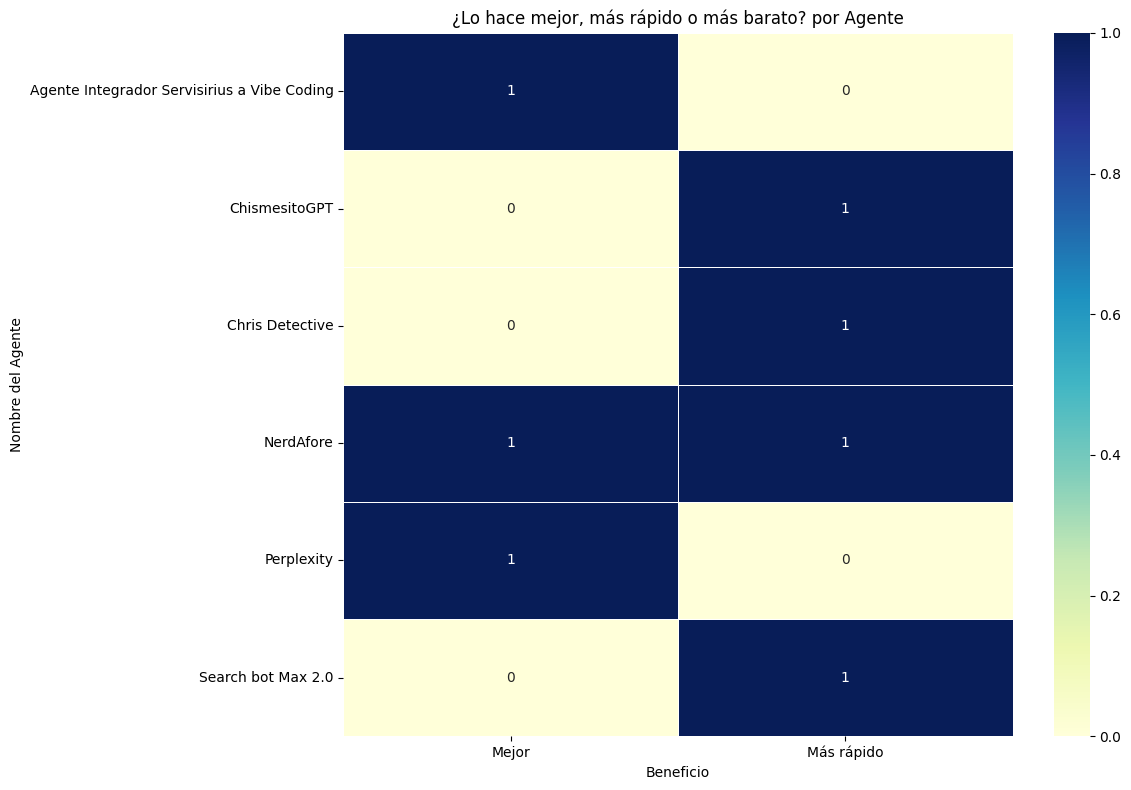

In [110]:
heatmap_mejora = pd.crosstab(
    df['Nombre del Agente'],
    df['¿Lo hace mejor, más rápido o más barato?\n']
)

display(heatmap_mejora)

plt.figure(figsize=(12,8))

sns.heatmap(
    heatmap_mejora,
    annot=True,
    fmt='g',
    cmap='YlGnBu',
    linewidths=0.5
)

plt.title('¿Lo hace mejor, más rápido o más barato? por Agente')
plt.xlabel('Beneficio')
plt.ylabel('Nombre del Agente')

plt.tight_layout()
plt.show()

In [111]:
df_perdidas = df.copy()

df_perdidas['Si el agente desaparece mañana\n¿Qué perderíamos?'] = (
    df_perdidas['Si el agente desaparece mañana\n¿Qué perderíamos?']
    .str.split(';')
)

df_perdidas = df_perdidas.explode(
    'Si el agente desaparece mañana\n¿Qué perderíamos?'
)

# Limpiar espacios
df_perdidas['Si el agente desaparece mañana\n¿Qué perderíamos?'] = (
    df_perdidas['Si el agente desaparece mañana\n¿Qué perderíamos?']
    .str.strip()
)

# Eliminar vacíos
df_perdidas = df_perdidas[
    df_perdidas['Si el agente desaparece mañana\n¿Qué perderíamos?'].notna()
]

df_perdidas = df_perdidas[
    df_perdidas['Si el agente desaparece mañana\n¿Qué perderíamos?'] != ''
]

display(
    df_perdidas[
        [
            'Nombre del Agente',
            'Si el agente desaparece mañana\n¿Qué perderíamos?'
        ]
    ].head(20)
)

,Nombre del Agente,Si el agente desaparece mañana\n¿Qué perderíamos?
0,NerdAfore,Velocidad
0,NerdAfore,Productividad
0,NerdAfore,Conocimiento
1,ChismesitoGPT,Productividad
1,ChismesitoGPT,Velocidad
2,Agente Integrador Servisirius a Vibe Coding,Productividad
2,Agente Integrador Servisirius a Vibe Coding,Velocidad
3,NerdAfore,Velocidad
4,Chris Detective,Velocidad
4,Chris Detective,Conocimiento


Si el agente desaparece mañana ¿Qué perderíamos?,Atención personalizada,Conocimiento,Nada importante,Productividad,Velocidad
Nombre del Agente,,,,,
Agente Integrador Servisirius a Vibe Coding,0,0,0,1,1
ChismesitoGPT,0,0,0,1,1
Chris Detective,0,1,1,0,1
NerdAfore,0,1,0,1,2
Perplexity,0,0,0,1,1
Search bot Max 2.0,1,0,0,1,1


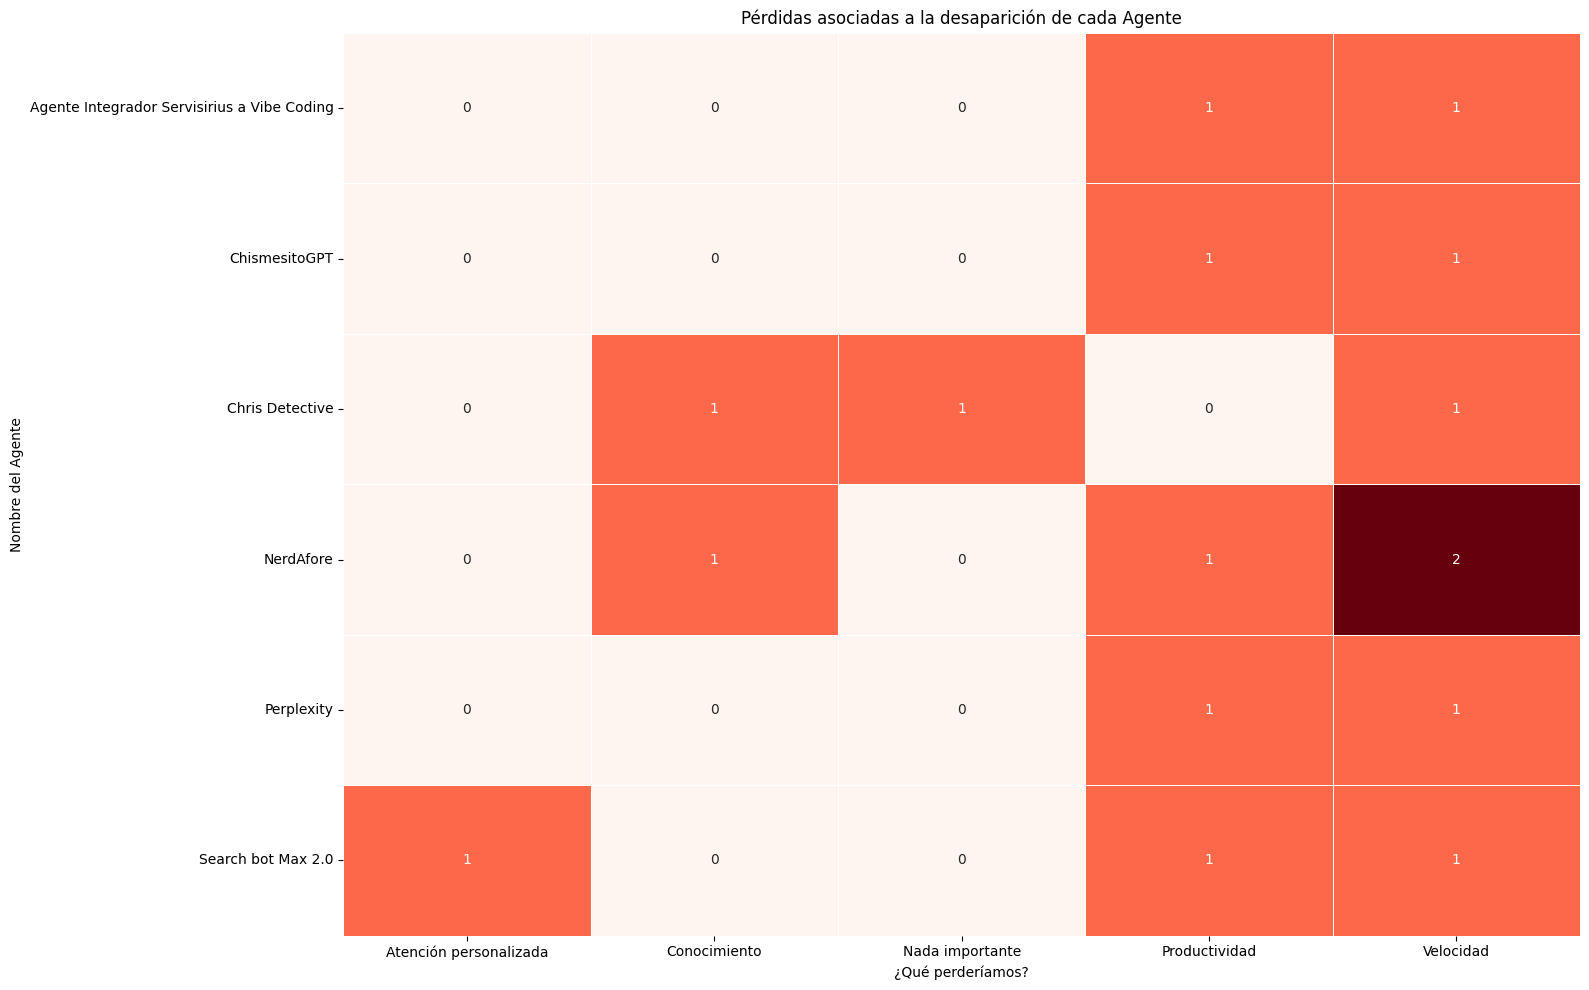

In [112]:
heatmap_perdidas = pd.crosstab(
    df_perdidas['Nombre del Agente'],
    df_perdidas['Si el agente desaparece mañana\n¿Qué perderíamos?']
)

display(heatmap_perdidas)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16,10))

sns.heatmap(
    heatmap_perdidas,
    annot=True,
    cmap='Reds',
    cbar=False,
    linewidths=0.5
)

plt.title('Pérdidas asociadas a la desaparición de cada Agente')
plt.xlabel('¿Qué perderíamos?')
plt.ylabel('Nombre del Agente')

plt.tight_layout()
plt.show()

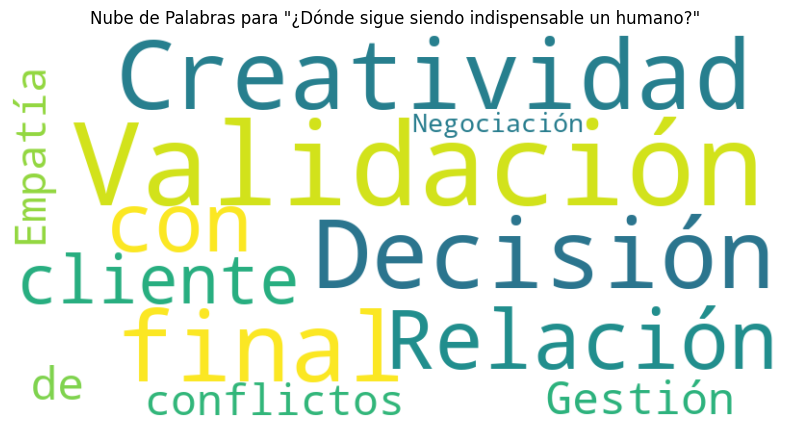

In [113]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Obtener el texto de la columna deseada
text_data = df['¿Dónde sigue siendo indispensable un humano?'].dropna().astype(str)

# Unir todo el texto en una sola cadena, separando las palabras por comas y limpiando
all_words = []
for entry in text_data:
    words = [word.strip() for word in entry.split(';') if word.strip()]
    all_words.extend(words)

long_string = " ".join(all_words)

# Crear el objeto WordCloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(long_string)

# Mostrar la nube de palabras
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title('Nube de Palabras para "¿Dónde sigue siendo indispensable un humano?"')
plt.show()

In [114]:
# Separar necesidades en filas
df_faltantes = df.copy()

df_faltantes['¿Qué le falta al agente?'] = (
    df_faltantes['¿Qué le falta al agente?']
    .str.split(';')
)

df_faltantes = df_faltantes.explode('¿Qué le falta al agente?')

# Limpiar espacios
df_faltantes['¿Qué le falta al agente?'] = (
    df_faltantes['¿Qué le falta al agente?']
    .str.strip()
)

# Eliminar vacíos
df_faltantes = df_faltantes[
    df_faltantes['¿Qué le falta al agente?'].notna()
]

df_faltantes = df_faltantes[
    df_faltantes['¿Qué le falta al agente?'] != ''
]

display(
    df_faltantes[
        ['Nombre del Agente', '¿Qué le falta al agente?']
    ].head(20)
)

,Nombre del Agente,¿Qué le falta al agente?
0,NerdAfore,Más casos de uso
0,NerdAfore,Más datos
1,ChismesitoGPT,Mejor UX
1,ChismesitoGPT,Mejor integración
1,ChismesitoGPT,Más datos
1,ChismesitoGPT,Mayor autonomía
1,ChismesitoGPT,Mejor explicabilidad
1,ChismesitoGPT,Mejor adopción
1,ChismesitoGPT,Más casos de uso
1,ChismesitoGPT,Mejor precisión


¿Qué le falta al agente?,Mayor autonomía,Mejor UX,Mejor adopción,Mejor contexto,Mejor explicabilidad,Mejor integración,Mejor precisión,Más casos de uso,Más datos
Nombre del Agente,,,,,,,,,
Agente Integrador Servisirius a Vibe Coding,1,1,1,1,1,1,1,1,1
ChismesitoGPT,1,1,1,1,1,1,1,1,1
Chris Detective,0,1,0,1,0,0,1,0,0
NerdAfore,0,0,1,1,0,0,0,1,1
Perplexity,0,1,0,0,0,0,0,1,0
Search bot Max 2.0,0,1,0,0,0,1,1,0,0


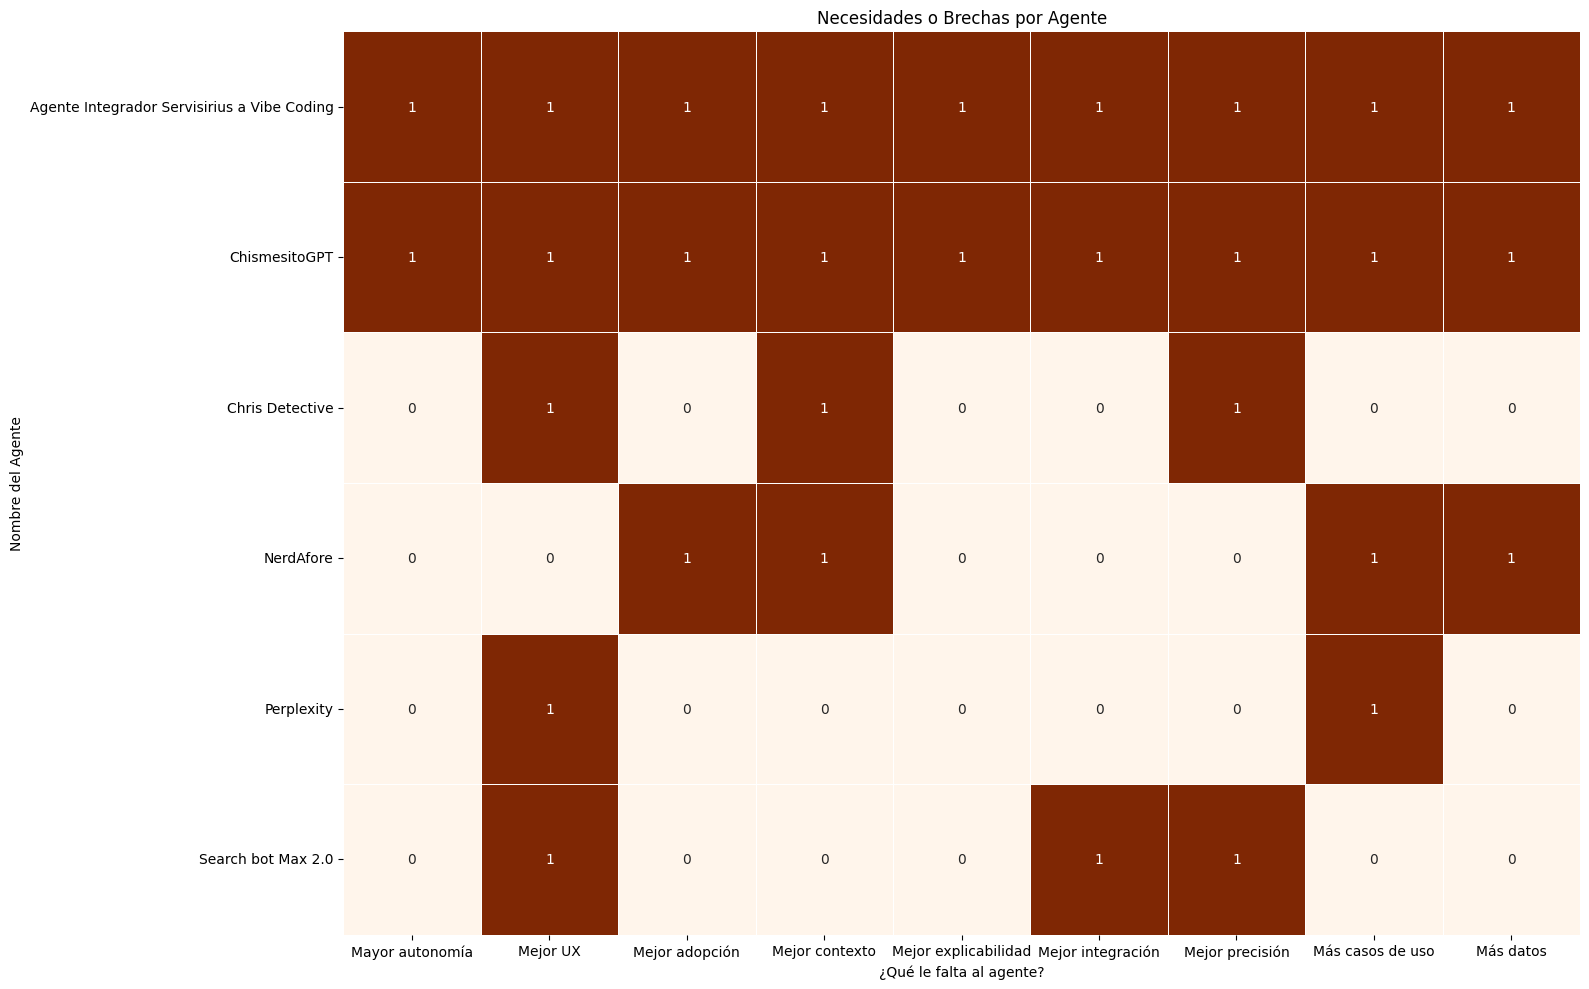

In [115]:
heatmap_faltantes = pd.crosstab(
    df_faltantes['Nombre del Agente'],
    df_faltantes['¿Qué le falta al agente?']
)

display(heatmap_faltantes)

plt.figure(figsize=(16,10))

sns.heatmap(
    heatmap_faltantes,
    annot=True,
    cmap='Oranges',
    cbar=False,
    linewidths=0.5
)

plt.title('Necesidades o Brechas por Agente')
plt.xlabel('¿Qué le falta al agente?')
plt.ylabel('Nombre del Agente')

plt.tight_layout()
plt.show()

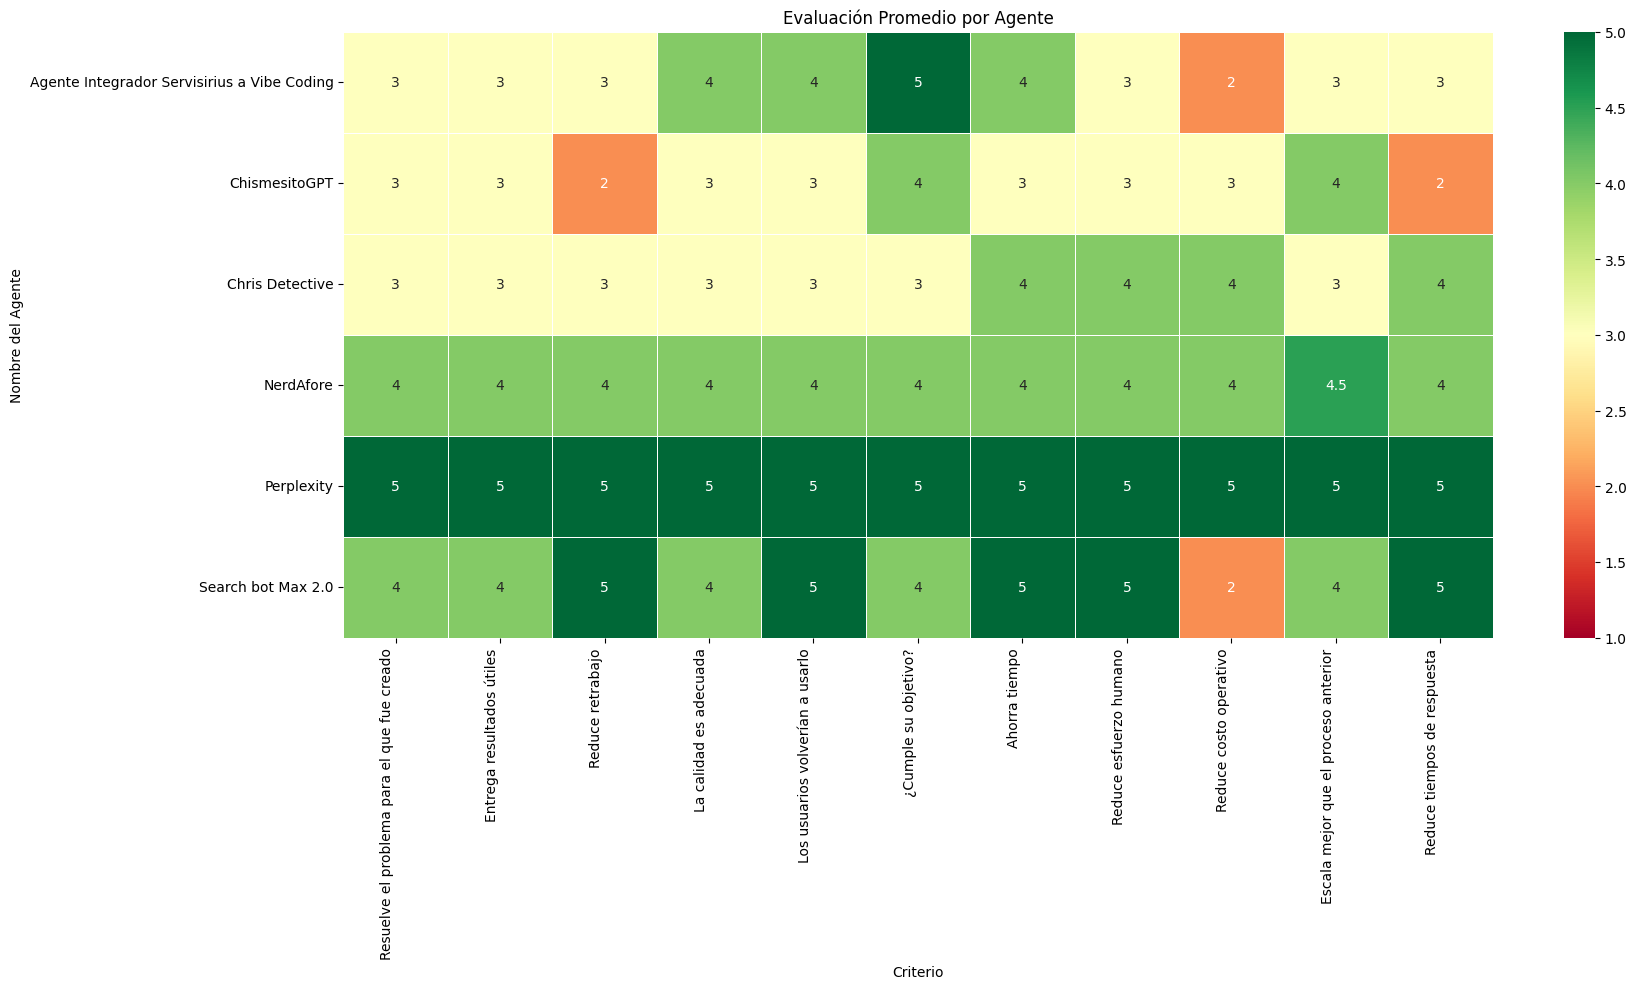

In [116]:
metricas = [
    'Resuelve el problema para el que fue creado\n',
    'Entrega resultados útiles\n',
    'Reduce retrabajo\n',
    'La calidad es adecuada\n',
    'Los usuarios volverían a usarlo\n',
    '¿Cumple su objetivo?\n',
    'Ahorra tiempo\n',
    'Reduce esfuerzo humano\n',
    'Reduce costo operativo\n',
    'Escala mejor que el proceso anterior\n',
    'Reduce tiempos de respuesta\n'
]

heatmap_df = (
    df.groupby('Nombre del Agente')[metricas]
    .mean()
)

plt.figure(figsize=(18,10))

sns.heatmap(
    heatmap_df,
    annot=True,
    cmap='RdYlGn',
    vmin=1,
    vmax=5,
    linewidths=.5
)

plt.title('Evaluación Promedio por Agente')
plt.xlabel('Criterio')
plt.ylabel('Nombre del Agente')

plt.tight_layout()
plt.show()

<Axes: ylabel='Nombre del Agente'>

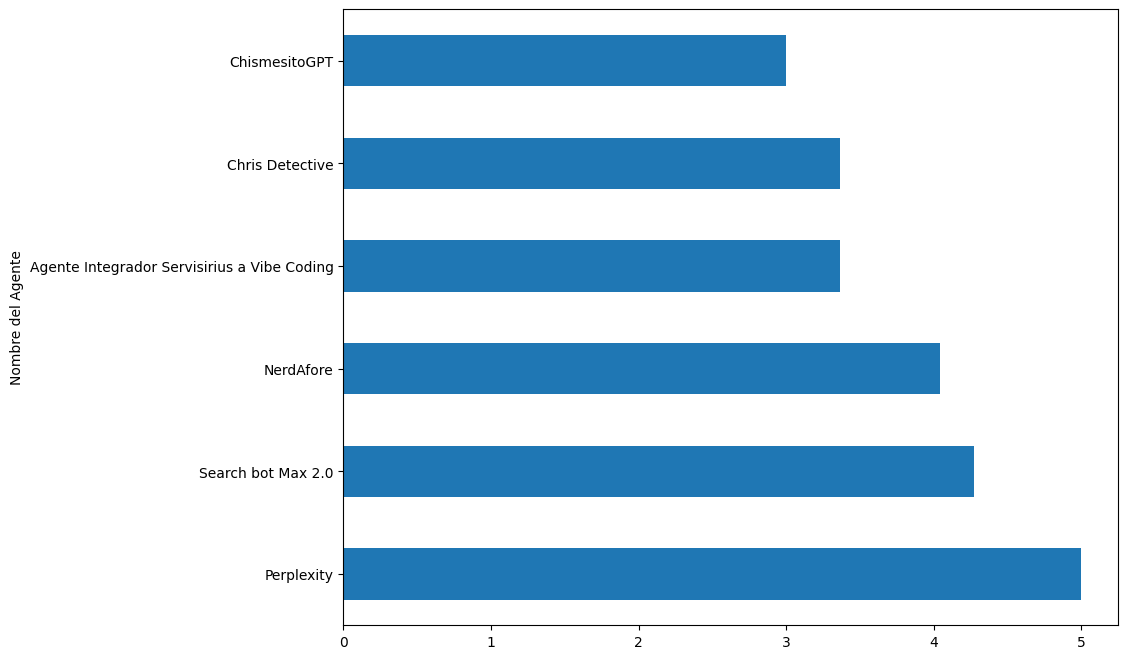

In [119]:
df['Score General'] = df[metricas].mean(axis=1)

ranking = (
    df.groupby('Nombre del Agente')['Score General']
    .mean()
    .sort_values(ascending=False)
)
ranking.plot.barh(figsize=(10,8))

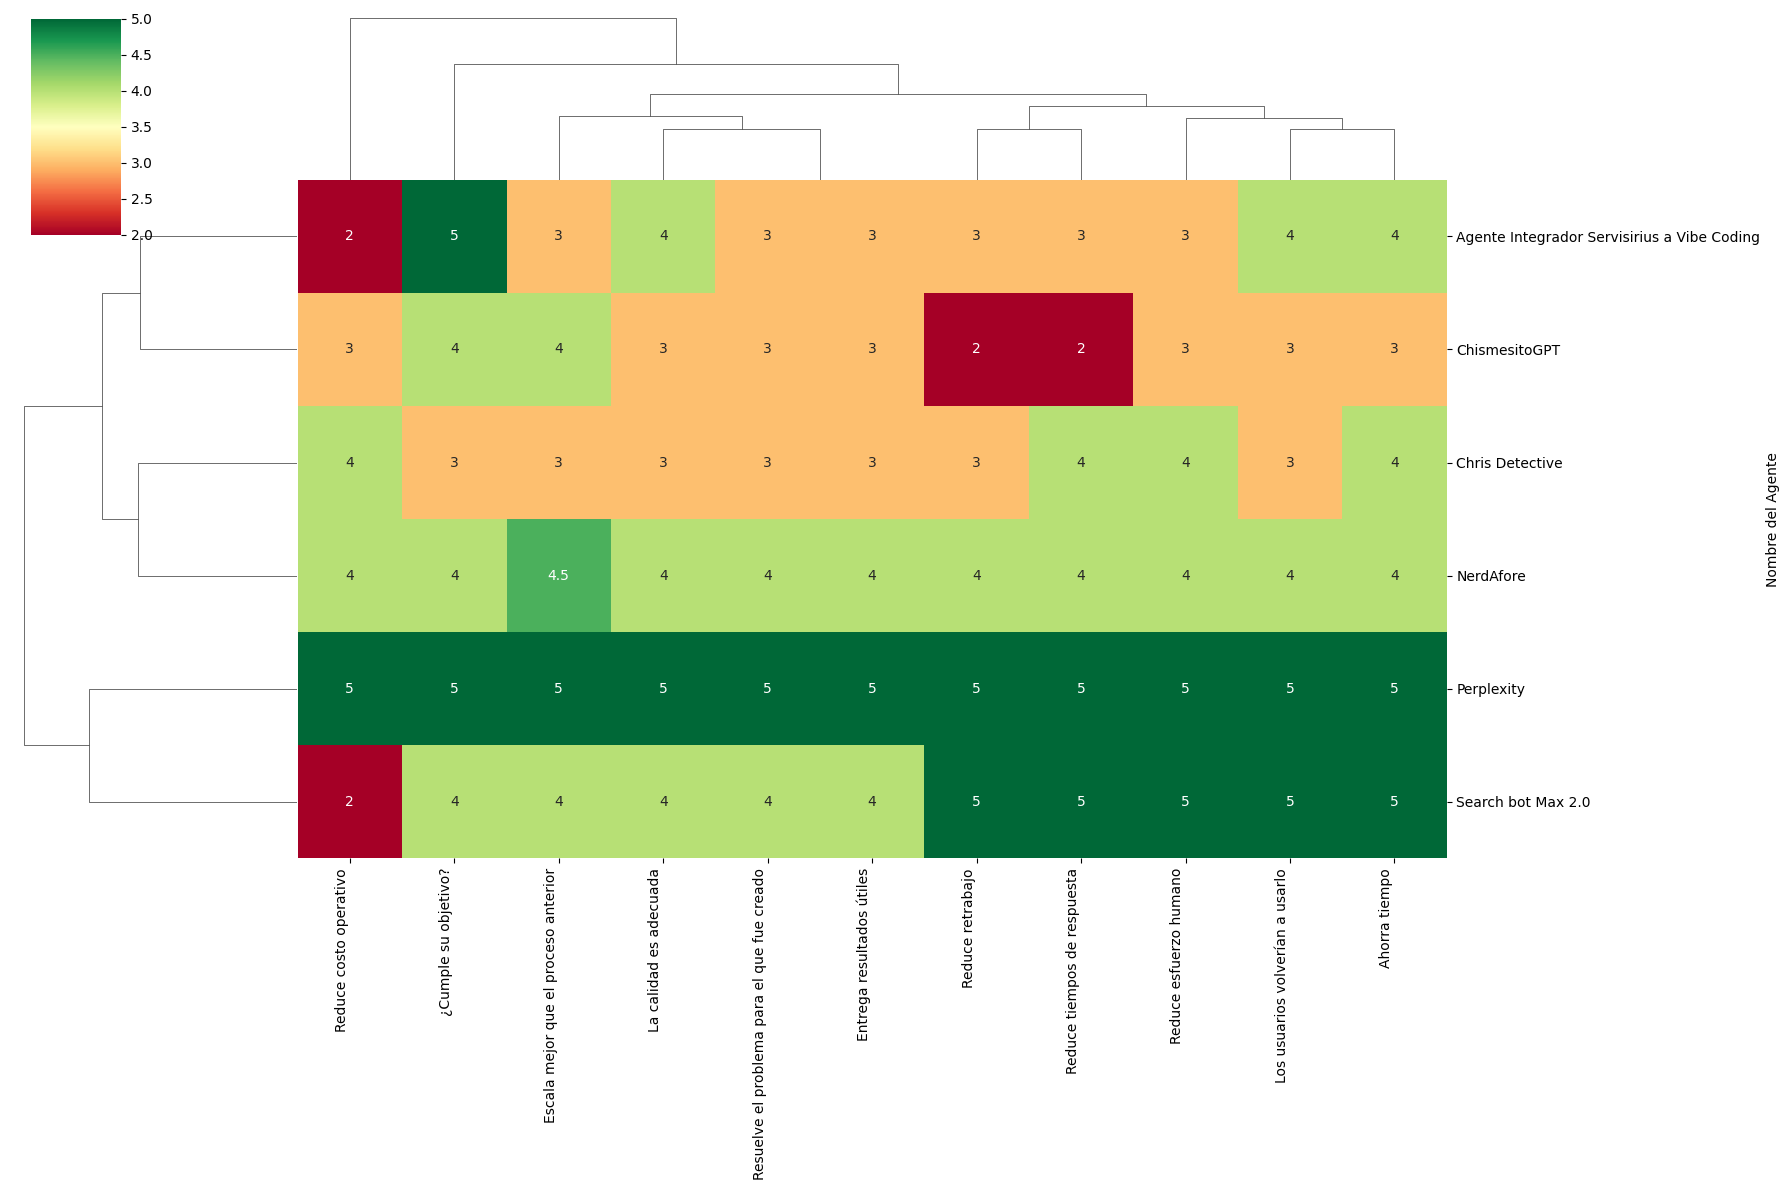

In [120]:
sns.clustermap(
    heatmap_df,
    cmap='RdYlGn',
    figsize=(18,12),
    annot=True
)

In [122]:
def extract_baseline(text):
    if pd.isna(text):
        return np.nan

    text = str(text)

    nums = re.findall(r'\d+\.?\d*', text)

    if len(nums) == 0:
        return np.nan

    # Caso "de 8 horas a 1 hora"
    if 'de' in text.lower() and len(nums) >= 2:
        return float(nums[0])

    return float(nums[0])

df['Baseline Horas'] = df[
    '¿Cuál es el baseline del agente?(Cuántas horas demoraría la misma tarea en hacerse si no contáramos con el agente)'
].apply(extract_baseline)

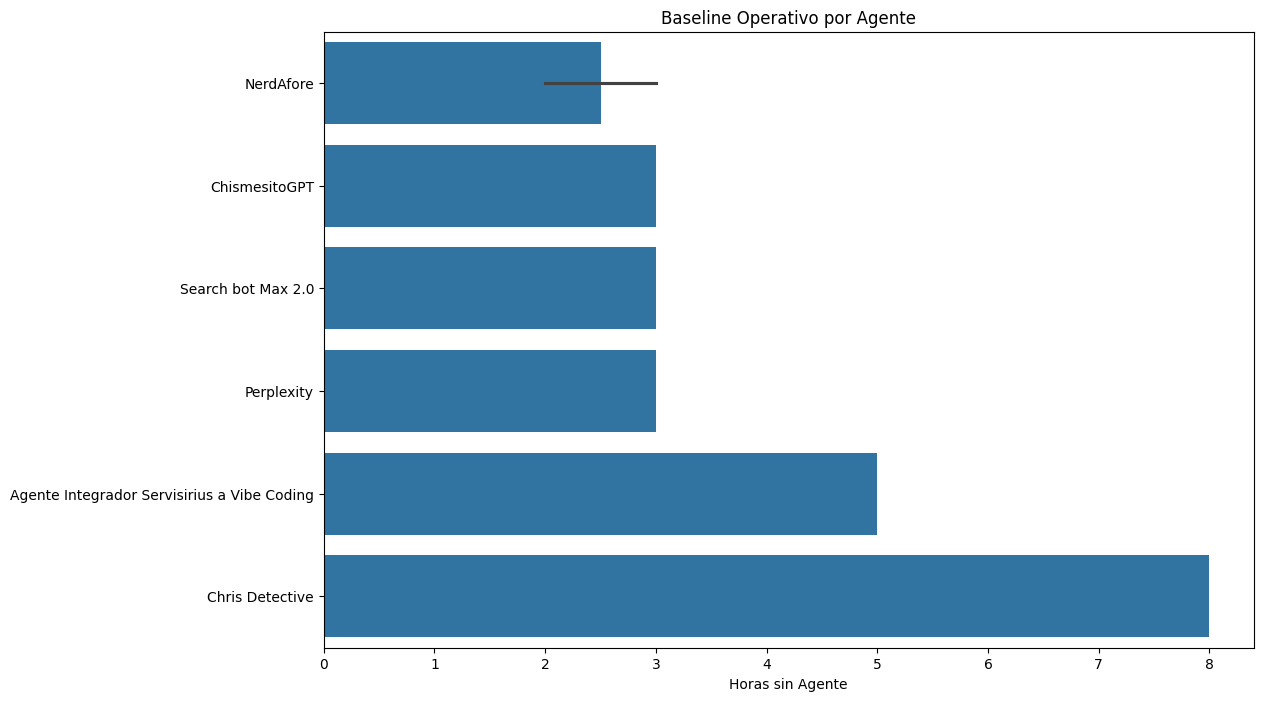

In [124]:
baseline_df = (
    df[['Nombre del Agente','Baseline Horas']]
    .sort_values('Baseline Horas')
)

plt.figure(figsize=(12,8))

sns.barplot(
    data=baseline_df,
    y='Nombre del Agente',
    x='Baseline Horas'
)

plt.xlabel('Horas sin Agente')
plt.ylabel('')
plt.title('Baseline Operativo por Agente')

plt.show()

In [127]:
df[['Nombre del Agente', '¿Cómo resolverían este problema antes de tener el agente?']]

,Nombre del Agente,¿Cómo resolverían este problema antes de tener el agente?
0,NerdAfore,Una búsqueda página por página de la CONSAR y ...
1,ChismesitoGPT,Web scraping totalmente manual
2,Agente Integrador Servisirius a Vibe Coding,Usar diferentes agentes paso a paso
3,NerdAfore,Buscando en distintos documentos o tomando con...
4,Chris Detective,investigación en motores de búsqueda y a veces...
5,Search bot Max 2.0,"A mano, ya existía un proceso de búsqueda conc..."
6,Perplexity,Se ocuparía mayor cantidad de atención de miem...


In [128]:
df[['Nombre del Agente', '¿En qué tareas y/o actividades se ha probado el agente?']]

,Nombre del Agente,¿En qué tareas y/o actividades se ha probado el agente?
0,NerdAfore,En el proyecto de AFORE
1,ChismesitoGPT,En diversas tareas de web scraping
2,Agente Integrador Servisirius a Vibe Coding,"Aún no se ha probado, pero es totalmente prome..."
3,NerdAfore,"EN EL ENTENDIMIENTO DE LA NORMATIVIDAD,"
4,Chris Detective,se probó con tendencias que habíamos investiga...
5,Search bot Max 2.0,"Para buscar y encontrar más rápido estudios, i..."
6,Perplexity,Investigación
